### Checking the trends of deliveriies by month
 If Veridi's late delivery rate is increasing month by month, the business is at serious risk. Customers who receive late deliveries leave bad reviews, losetrust in the platform, and are unlikely to return. If this trend is worsening over time, Veridi faces a compounding problem , each month more customers are being failed, meaning fewer repeat purchases, more negative word of mouth, and eventual revenue decline.

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [31]:
df = pd.read_csv(os.path.join("../Merged_Olist_Data", "Last_Mile_Master_Sheet.csv"))


In [32]:
df = pd.read_csv(os.path.join("../Merged_Olist_Data", "delivery_analysis.csv"))
df["is_late"] = df["Delivery_Status"].isin(["Late", "Super Late"])

print(f"Shape: {df.shape}")
print(f"Total late orders: {df['is_late'].sum()}")
print(f"Overall late rate: {df['is_late'].mean()*100:.1f}%")

Shape: (98207, 21)
Total late orders: 7826
Overall late rate: 8.0%


### Extract Year-Month from Purchase Timestamp

In [33]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])
df["year_month"] = df["order_purchase_timestamp"].dt.to_period("M")

print(f"Date range: {df['order_purchase_timestamp'].min()} to {df['order_purchase_timestamp'].max()}")
print(f"\nOrders per month:")
print(df["year_month"].value_counts().sort_index())

Date range: 2016-09-04 21:15:19 to 2018-09-03 09:06:57

Orders per month:
year_month
2016-09       2
2016-10     293
2016-12       1
2017-01     787
2017-02    1718
2017-03    2617
2017-04    2377
2017-05    3640
2017-06    3205
2017-07    3946
2017-08    4272
2017-09    4227
2017-10    4547
2017-11    7423
2017-12    5620
2018-01    7187
2018-02    6625
2018-03    7168
2018-04    6919
2018-05    6833
2018-06    6145
2018-07    6233
2018-08    6421
2018-09       1
Freq: M, Name: count, dtype: int64


## Step 3: Calculate Monthly Late Rate
For each month we calculate:
- **Total orders** placed that month
- **Late orders** — those classified as Late or Super Late
- **% Late** — the percentage of orders that failed that month

We filter out months with fewer than 50 orders to avoid
misleading spikes from months with very little data.

In [34]:
monthly_trend = (
    df.groupby("year_month")
    .agg(
        total_orders=("order_id", "count"),
        late_orders=("is_late", "sum")
    )
    .reset_index()
)

monthly_trend["percentage_late"] = (
    monthly_trend["late_orders"] / monthly_trend["total_orders"] * 100
).round(2)

monthly_trend["year_month_str"] = monthly_trend["year_month"].astype(str)

# Filter out months with very few orders
monthly_trend = monthly_trend[monthly_trend["total_orders"] >= 50]

print(monthly_trend[["year_month_str", "total_orders", "late_orders", "percentage_late"]])

   year_month_str  total_orders  late_orders  percentage_late
1         2016-10           293            3             1.02
3         2017-01           787           23             2.92
4         2017-02          1718           53             3.08
5         2017-03          2617          142             5.43
6         2017-04          2377          181             7.61
7         2017-05          3640          128             3.52
8         2017-06          3205          121             3.78
9         2017-07          3946          133             3.37
10        2017-08          4272          139             3.25
11        2017-09          4227          216             5.11
12        2017-10          4547          237             5.21
13        2017-11          7423         1043            14.05
14        2017-12          5620          462             8.22
15        2018-01          7187          464             6.46
16        2018-02          6625         1048            15.82
17      

## Step 4: Visualize the Monthly Trend
The red line shows the actual late delivery rate each month.
The orange dotted line shows the overall average.

**How to read this chart:**
- Trend line sloping **upward** → problem is getting WORSE month by month
- Trend line sloping **downward** → problem is improving month by month
- Spikes above the average line → particularly bad months to investigate

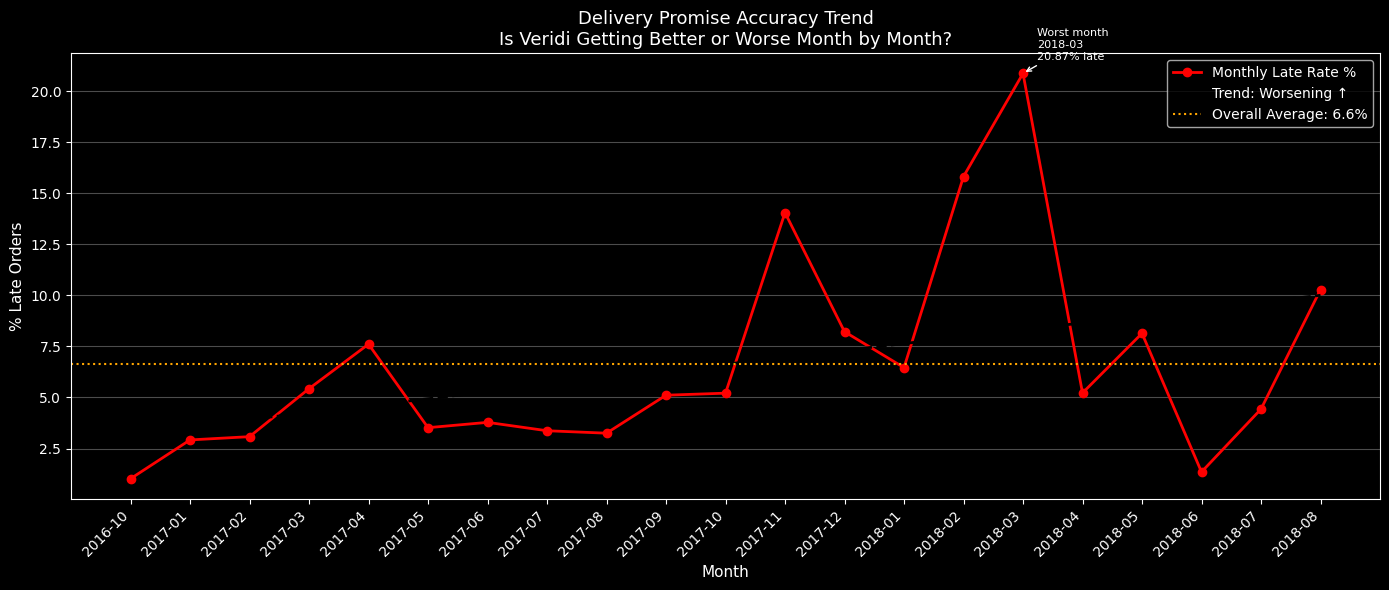

Monthly trend chart saved


In [35]:
fig, ax = plt.subplots(figsize=(14, 6))

# Plot actual monthly rate
ax.plot(
    monthly_trend["year_month_str"],
    monthly_trend["percentage_late"],
    marker="o",
    color="red",
    linewidth=2,
    markersize=6,
    label="Monthly Late Rate %"
)

# Add trend line
x_nums = np.arange(len(monthly_trend))
z = np.polyfit(x_nums, monthly_trend["percentage_late"], 1)
p = np.poly1d(z)
trend_direction = "Worsening ↑" if z[0] > 0 else "Improving ↓"

ax.plot(
    monthly_trend["year_month_str"],
    p(x_nums),
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Trend: {trend_direction}"
)

# Add average line
avg_late = monthly_trend["percentage_late"].mean()
ax.axhline(
    y=avg_late,
    color="orange",
    linestyle=":",
    linewidth=1.5,
    label=f"Overall Average: {avg_late:.1f}%"
)

# Highlight worst month
worst_month = monthly_trend.loc[monthly_trend["percentage_late"].idxmax()]
ax.annotate(
    f"Worst month\n{worst_month['year_month_str']}\n{worst_month['percentage_late']}% late",
    xy=(worst_month["year_month_str"], worst_month["percentage_late"]),
    xytext=(10, 10),
    textcoords="offset points",
    fontsize=8,
    color="white",
    arrowprops=dict(arrowstyle="->", color="white")
)

ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("% Late Orders", fontsize=11)
ax.set_title(
    "Delivery Promise Accuracy Trend\nIs Veridi Getting Better or Worse Month by Month?",
    fontsize=13
)
plt.xticks(rotation=45, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join("../Charts", "monthly_trend_chart.png"), dpi=150)
plt.show()
print("Monthly trend chart saved")

## Key Findings


In [36]:
best_month = monthly_trend.loc[monthly_trend["percentage_late"].idxmin()]
worst_month = monthly_trend.loc[monthly_trend["percentage_late"].idxmax()]

print("=" * 50)
print("MONTHLY TREND KEY FINDINGS")
print("=" * 50)
print(f"Date range analysed : {monthly_trend['year_month_str'].iloc[0]} to {monthly_trend['year_month_str'].iloc[-1]}")
print(f"Overall average     : {avg_late:.1f}% late per month")
print(f"Best month          : {best_month['year_month_str']} ({best_month['percentage_late']}% late)")
print(f"Worst month         : {worst_month['year_month_str']} ({worst_month['percentage_late']}% late)")
print(f"Trend direction     : {trend_direction}")
print()
if z[0] > 0:
    print("⚠️  WARNING: Late delivery rate is WORSENING over time.")
    print("   Urgent action required to prevent further customer loss.")
else:
    print("POSITIVE: Late delivery rate is IMPROVING over time.")
    print("   Current efforts are working but monitoring should continue.")
print("=" * 50)

MONTHLY TREND KEY FINDINGS
Date range analysed : 2016-10 to 2018-08
Overall average     : 6.6% late per month
Best month          : 2016-10 (1.02% late)
Worst month         : 2018-03 (20.87% late)
Trend direction     : Worsening ↑

⚠️  WARNING: Late delivery rate is WORSENING over time.
   Urgent action required to prevent further customer loss.


In [37]:
monthly_trend.to_csv(os.path.join("../Merged_Olist_Data", "monthly_trend.csv"), index=False)
print("monthly_trend.csv saved")

monthly_trend.csv saved
